# ChromatoNet examples

ChromatoNet is a biophysical model of chromatophore networks in cephalopod skin. Each chromatophore is tethered to the skin by a spring and connected to its neighbors by radial muscles. Each muscle is an excitable active spring whose membrane voltage follows modified Morris–Lecar dynamics, with a stretch-sensitive calcium current and gap junction coupling between muscles. With little or no central input, the network produces traveling waves, spiral waves, periodic patterns and spontaneous flickering, similar to those seen in live and denervated cephalopod skin.

This notebook walks through the main features of the model:

1. Setting up the environment
2. A 1D chain of chromatophores
3. Radius and voltage traces in 1D
4. A 2D lattice at rest and with an initial voltage stimulus
5. The 2D network connections
6. Radius and voltage traces in 2D
7. Periodic input
8. Local changes to parameters, such as stiff regions
9. Random removal of muscle connections
10. A larger 2D example

**Files**

- `chromatonet.py`: The model (`ChromatoNet`).
- `defaults.py`: Default parameter values, update prior to importing ChromatoNet to change parameters easily.
- `stims.py`: Initial voltages, applied currents, initial positions and parameter maps.
- `animate_module.py`: Animations of saved simulations.
- `requirements.txt`: Required Python packages.

If you use ChromatoNet, please cite: Ersoy Y, et al. *ChromatoNet: Bio-inspired chromatophore network model generates dynamic skin patterns akin to those observed in cephalopods.* [citation and GitHub link placeholder]

## Setting up your environment

ChromatoNet was tested with **Python 3.11.13**. We recommend a separate virtual environment. Either use the interactive option to choose Python 3.11.13 in VS notebook or in a terminal, from the folder containing this notebook:

```bash
python3.11 -m venv .venv
source .venv/bin/activate # On Windows: .venv\Scripts\activate
pip install jupyter
jupyter notebook
```

Run the cell below to install the remaining packages once. If you prefer, you can instead run `pip install -r requirements.txt` in the terminal and skip the next cell.

**GPU note:** ChromatoNet runs on CPU by default and uses a CUDA GPU automatically if one is available. On Linux with an NVIDIA GPU, you may need the PyTorch install command for your CUDA version from [pytorch.org](https://pytorch.org).

In [ ]:
# Run this cell once to set up your environment.
# It installs the packages in requirements.txt into the environment this notebook is running in.
# Restart the kernel afterwards (Kernel > Restart) so the newly installed packages are loaded.
%pip install -r requirements.txt

## Imports

**Run this cell before any of the examples below.** Every example depends on these imports and settings, so if you restart the kernel, run it again first.  If you would like default parameters changed please update `defaults.py`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display

import chromatonet as cn
import stims
import animate_module as an
import plot_helper as ph
# import calc_helper as ch

# Show animations in the notebook without needing ffmpeg
plt.rcParams['animation.html'] = 'jshtml'
plt.rcParams['animation.embed_limit'] = 100  # MB

print(f"torch {torch.__version__}, numpy {np.__version__}")
print("CUDA GPU available:", torch.cuda.is_available())
print("Imports ok")

torch 2.3.1, numpy 2.3.3
CUDA GPU available: False
Imports ok


## 1D chain: A mechanical pull

A chain of 50 chromatophores with both end chromatophores held fixed. We start a wave mechanically by pulling the second chromatophore 0.25 units to the left (the first one is a fixed boundary). This stretches the muscle to its right past the calcium threshold, which depolarizes that muscle, and the wave travels down the chain from there.

In [2]:
# Settings (gl and ks from Table 1)
N_chain = 50
dt = 0.1
total_time = 200
steps = int(total_time / dt)
save_freq = int(1 / dt)          # Save once per second
params = {'gl': lambda p: 0.42, 'ks': lambda p: 0.5}
name_1d = 'demo_1d_pull'

chain = cn.ChromatoNet(N=N_chain, layout='chain', params=params,
                                 integration_method='rk4')

# Pull the second chromatophore 0.25 to the left; all others start at rest
chain.reset_net(xi=lambda z: stims.xi_displace(z, center=(1., 0.), shift=(-0.25, 0.)))

vals = chain.run(steps, name=name_1d, dt=dt, save_freq=save_freq)

Using device: cpu
Step 1000/2000, 284.4 steps/sec, ETA: 3.5s
Step 2000/2000, 287.5 steps/sec, ETA: 0.0s


In [3]:
anim = an.animate(name_1d)
plt.close()  # Show only the animation, not an extra static frame.
anim

### Probing one chromatophore

Left: the chain around chromatophore 15 (red), with its two muscles in color. Right: the radius of chromatophore 15, and the voltage of each of its muscles in the matching color. The muscle on the side the wave comes from depolarizes first, then the chromatophore opens.

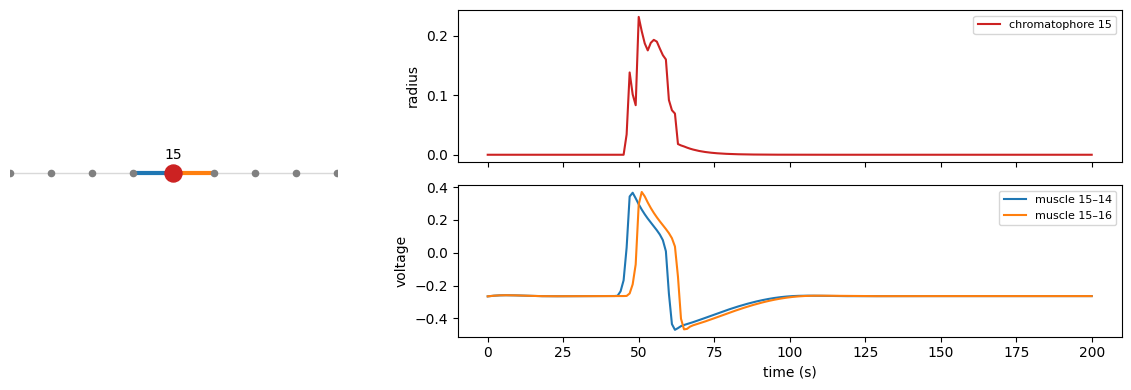

In [4]:
fig, axes = ph.plot_probe(chain, name_1d, chromat_idx=15, window=4)
plt.show()